In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error,mean_absolute_error
import pandas as pd
from google.colab import files
from sklearn.preprocessing import LabelEncoder,StandardScaler
uploaded=files.upload()

Saving Bengaluru_House_Data.csv to Bengaluru_House_Data.csv


In [ ]:
df=pd.read_csv('Bengaluru_House_Data.csv')
df=df[['area_type','size','total_sqft','bath','balcony','price','society','location','availability']]
df=pd.DataFrame(df)
print(df)

                  area_type       size total_sqft  bath  balcony   price  \
0      Super built-up  Area      2 BHK       1056   2.0      1.0   39.07   
1                Plot  Area  4 Bedroom       2600   5.0      3.0  120.00   
2            Built-up  Area      3 BHK       1440   2.0      3.0   62.00   
3      Super built-up  Area      3 BHK       1521   3.0      1.0   95.00   
4      Super built-up  Area      2 BHK       1200   2.0      1.0   51.00   
...                     ...        ...        ...   ...      ...     ...   
13315        Built-up  Area  5 Bedroom       3453   4.0      0.0  231.00   
13316  Super built-up  Area      4 BHK       3600   5.0      NaN  400.00   
13317        Built-up  Area      2 BHK       1141   2.0      1.0   60.00   
13318  Super built-up  Area      4 BHK       4689   4.0      1.0  488.00   
13319  Super built-up  Area      1 BHK        550   1.0      1.0   17.00   

       society                  location   availability  
0      Coomee   Electronic Ci

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(df.index)

Index([    0,     1,     3,     5,    11,    12,    14,    15,    16,    17,
       ...
       13294, 13295, 13297, 13298, 13304, 13308, 13314, 13315, 13317, 13318],
      dtype='int64', length=7144)


In [ ]:
print(df.dtypes)

area_type        object
size             object
total_sqft       object
bath            float64
balcony         float64
price           float64
society          object
location         object
availability     object
dtype: object


In [ ]:
#extracting numbers from size(bhk)
df['size'] = df['size'].astype(str).str.extract(r'(\d+)', expand=False).astype(float)

print(df['size'])

0        2.0
1        4.0
3        3.0
5        2.0
11       4.0
        ... 
13308    3.0
13314    3.0
13315    5.0
13317    2.0
13318    4.0
Name: size, Length: 7144, dtype: float64


In [ ]:
#encoding area type
la=LabelEncoder()
df['area_type']=la.fit_transform(df['area_type'])
print(df['area_type'])

0        3
1        2
3        3
5        3
11       2
        ..
13308    0
13314    3
13315    0
13317    0
13318    3
Name: area_type, Length: 7144, dtype: int64


In [ ]:
#encoding society type
la=LabelEncoder()
df['society']=la.fit_transform(df['society'])
print(df['society'])

0         443
1        2353
3        2109
5         585
11       1566
         ... 
13308     262
13314    2148
13315     197
13317    1168
13318    2127
Name: society, Length: 7144, dtype: int64


In [ ]:
#encoding location type
df['location'] = df['location'].astype(str)
la=LabelEncoder()
df['location']=la.fit_transform(df['location'])
print(df['location'])

0        210
1        149
3        387
5        625
11       625
        ... 
13308     91
13314    234
13315    625
13317    490
13318    459
Name: location, Length: 7144, dtype: int64


In [ ]:
#converting sqft to float
def convert_sqft_to_float(x):
    try:
        if isinstance(x, str) and '-' in x:
            tokens = [float(t) for t in x.split('-')]
            return sum(tokens) / len(tokens)
        return float(x)
    except (ValueError, TypeError):
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_float)

df.dropna(subset=['total_sqft'], inplace=True)

print(df['total_sqft'])

0        1056.0
1        2600.0
3        1521.0
5        1170.0
11       2785.0
          ...  
13308    1527.0
13314    1715.0
13315    3453.0
13317    1141.0
13318    4689.0
Name: total_sqft, Length: 7129, dtype: float64


In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(df.index)

Index([    0,     1,     3,     5,    11,    12,    14,    15,    16,    17,
       ...
       13294, 13295, 13297, 13298, 13304, 13308, 13314, 13315, 13317, 13318],
      dtype='int64', length=7129)


In [ ]:
import numpy as np
df['availability_category'] = np.where(df['availability'].str.contains('Ready To Move'), 'Ready To Move', 'Date-based')
print(df[['availability', 'availability_category']].head())

     availability availability_category
0          19-Dec            Date-based
1   Ready To Move         Ready To Move
3   Ready To Move         Ready To Move
5   Ready To Move         Ready To Move
11  Ready To Move         Ready To Move


In [ ]:
la = LabelEncoder()
df['availability_category_encoded'] = la.fit_transform(df['availability_category'])
print(df[['availability_category', 'availability_category_encoded']].head())

   availability_category  availability_category_encoded
0             Date-based                              0
1          Ready To Move                              1
3          Ready To Move                              1
5          Ready To Move                              1
11         Ready To Move                              1


In [ ]:
print(df['availability_category_encoded'].value_counts())

availability_category_encoded
1    5445
0    1684
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X = df[['area_type', 'size', 'total_sqft', 'bath', 'balcony', 'society', 'location', 'availability_category_encoded']]
y = df['price']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (5703, 8)
Shape of x_test: (1426, 8)
Shape of y_train: (5703,)
Shape of y_test: (1426,)


In [ ]:
x=x_train
y=y_train

In [ ]:
model=LinearRegression()
model.fit(x_train, y_train)
pred_y_train=model.predict(x_train)
print("Intercept : ",model.intercept_)
print("Slope : ",model.coef_[0])
print("predicted y_train samples : ",pred_y_train)

Intercept :  -65.39672684836906
Slope :  -0.04166120110558712
predicted y_train samples :  [ 56.27728594  56.1034433   57.27243486 ...  73.16857027 112.62395096
  37.76064276]


In [ ]:
pred_y_test = model.predict(x_test)
print("mse :",mean_squared_error(y_test, pred_y_test))
print("rmse :",root_mean_squared_error(y_test, pred_y_test))
print("mae :",mean_absolute_error(y_test, pred_y_test))
print("r2 score :",r2_score(y_test, pred_y_test))

mse : 5768.985748730576
rmse : 75.95383959175847
mae : 29.16176778555683
r2 score : 0.2526300087947172


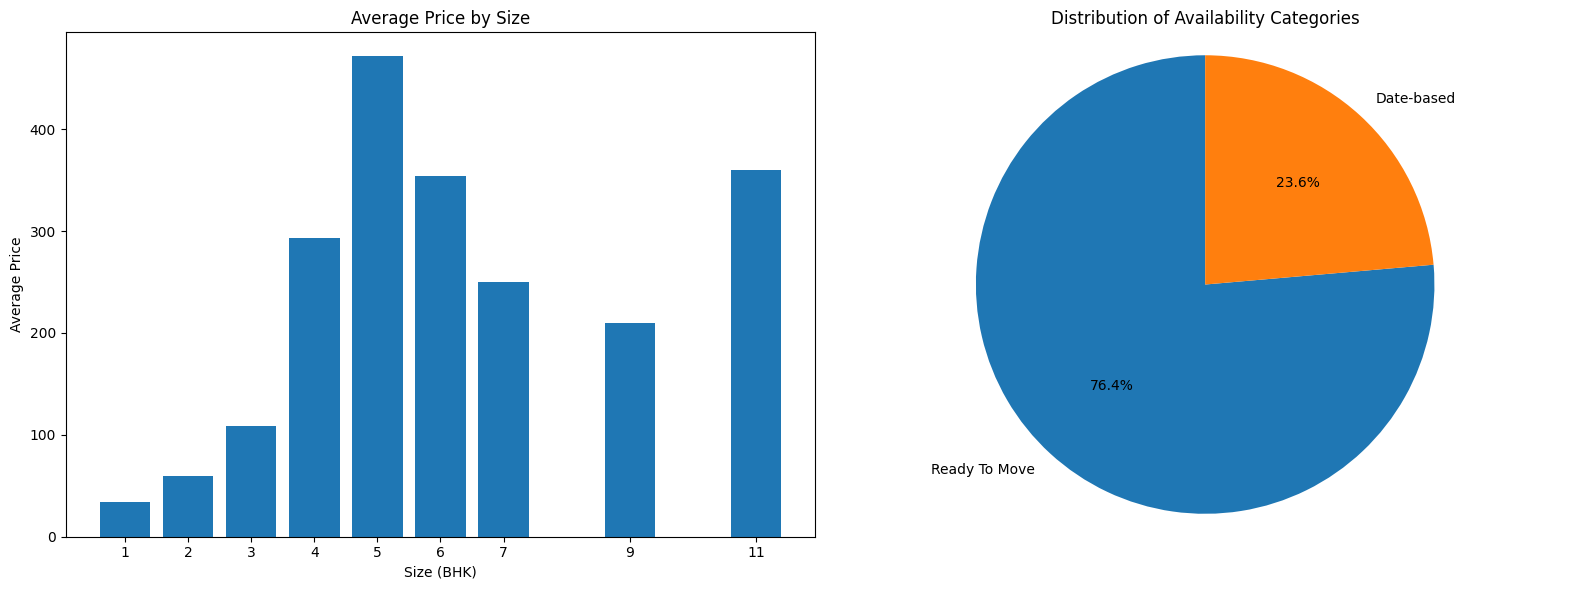

In [ ]:
x=df['price']
y=df['size']
z=df['area_type']
v=df['availability_category']

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
average_price_by_size = df.groupby('size')['price'].mean()
plt.bar(average_price_by_size.index, average_price_by_size.values)
plt.title("Average Price by Size")
plt.xlabel("Size (BHK)")
plt.ylabel("Average Price")
plt.xticks(average_price_by_size.index)

plt.subplot(1, 2, 2)
availability_counts = v.value_counts()
plt.pie(availability_counts, labels=availability_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Availability Categories")
plt.axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
X = df[['area_type', 'size', 'total_sqft', 'bath', 'balcony', 'society', 'location', 'availability_category_encoded']]
y = df['price']

print("X head:\n", X.head())
print("\ny head:\n", y.head())

X head:
     area_type  size  total_sqft  bath  balcony  society  location  \
0           3   2.0      1056.0   2.0      1.0      443       210   
1           2   4.0      2600.0   5.0      3.0     2353       149   
3           3   3.0      1521.0   3.0      1.0     2109       387   
5           3   2.0      1170.0   2.0      1.0      585       625   
11          2   4.0      2785.0   5.0      3.0     1566       625   

    availability_category_encoded  
0                               0  
1                               1  
3                               1  
5                               1  
11                              1  

y head:
 0      39.07
1     120.00
3      95.00
5      38.00
11    295.00
Name: price, dtype: float64
